## Implementación de Regresión Logística

### Tarea #2 Inteligencia Artificial

##### José Miguel González Barrantes / Emmanuel Rodríguez

Este notebook corresponde al de la tarea #2 mediante el uso de PyTorch para determinar la calidad del vino; determinar si es considerado como bueno o malo. Para ello se utilizará el data set de Kaggle sobre "Wine Quality Red".

### B) Análisis de Características (EDA)

##### **Cargar el data-set de Kaggle**

Para poder hacer el análisis logístico, primero se ocupa cargar el data-set de Kaggle como un data-frame de Pandas. Con ello podemos seguir con el EDA y así sucesivamente.

In [33]:
import pandas as pd
import numpy as np

df = pd.read_csv("winequality-red.csv")

print("Primeras 5 filas del dataset:")
display(df.head())

print("Cantidad de observaciones (filas):", df.shape[0])
print("Cantidad de variables (columnas):", df.shape[1])

Primeras 5 filas del dataset:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


Cantidad de observaciones (filas): 1599
Cantidad de variables (columnas): 12


##### **Revisión Previa del Data-Set**

Una vez que se haya cargado el data-set se debe revisar que todas las variables sean de tipo numéricas, que no haya valores nulos. En caso de que sí existan, se debe tomar registro de ello y además de determinar si existen duplicados o no.

##### **Información general del data-set**

A continuación se presenta información general sobre el data-set a estudiar.

In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


Como se puede observar, se observa el tipo de dato para cada una de las variables (columnas), además de la cantidad de datos que se tienen registrados en esa columna. Cada uno con su respectivo nombre e información. Se puede observar que, para cada observación (fila), se cuenta con 1 dato de cada columna.

##### **Descripción del data-set**

Cuando se hace referencia a la descripción breve de un data-set, se incluye el uso de datos como la media, desviación estándar, mínimos, máximos, y los distintos cuartiles. Esto para cada una de las variables (columnas); esto para tener un mejor entendimiento del mismo.

In [35]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


##### **Presencia de valores nulos**

La presencia de valores nulos pueden afectar estadísticas, gráficos y el entrenamiento. Por esta razón se busca la cantidad de nulos por columna y en todo el data-set.

In [36]:
print("Valores nulos por columna:")
print(df.isnull().sum())

print("Cantidad total de valores nulos en el dataset:", df.isnull().sum().sum())

Valores nulos por columna:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64
Cantidad total de valores nulos en el dataset: 0


No hay nulos! Perfecto; esto nos dice que no es necesario hacer eliminación de registros incompletos.

##### **Presencia de valores duplicados**

En el caso de los valores duplicados, estos pueden llegar a sesgar el modelo; esto hace que un aspecto parezca mejor de lo que realmente es.

In [37]:
print("Cantidad de filas duplicadas:", df.duplicated().sum())

Cantidad de filas duplicadas: 240


Como se puede observar, existen 240 filas duplicadas, esto es importante pues puede introducir sesgo en el análisis. En dónde se favorece algún factor. Se considera que es necesario hacer una elimicación de estos.

##### **Eliminación de valores duplicados**

Se considera que la técnica más adecuada para tratar estos datos duplicados es directamente mediante la eliminación de datos duplicados manteniendo solamente la primera aparición de estos. Esto para evitar inflar el rendimiento del modelo y entre otras consecuencias más. Si se tuviera datos faltantes, ruido, menor duplicación y errores de formato, se debería considerar otra opción, pero este no es el caso. 

In [38]:
df = df.drop_duplicates(keep='first')
print("Nuevo tamaño del dataset:", df.shape)

Nuevo tamaño del dataset: (1359, 12)


Se observa el nuevo tamaño del data-set, es muy importante hacer esto antes de dividir entre training, validation y test!

##### **Análisis de la variable objetivo**

Según el objetivo de la tarea es determinar la calidad del vino (saber si es buena o mala) a partir de un data-set, por lo tanto, se utilizará esta como variable objetivo. Mientras que las demás variables como por ejemplo: Alcohol, pH, Fixed Acidity, entre otras; se consideran como features para predecir una idea. Se debe pasar la variable a binaria pues es considerada como BUENA = 1 o MALA = 0.

##### **Pasar "Quality" como binaria**

Para ello se toma el valor de "Quality" de cada una de las filas y se analiza la idea de que si es mayor o igual a 6, entonces se considera como BUENA. En caso contrario, se considera como MALO.

In [39]:
df["quality_binary"] = (df["quality"] >= 6).astype(int)

print("\nDistribución de la variable binaria:")
print(df["quality_binary"].value_counts())

target = "quality_binary"

features = [col for col in df.columns if col not in ["quality_binary", "quality"]] #Descartamos el uso del quality (data leakage)
X = df[features]
y = df[target]


Distribución de la variable binaria:
quality_binary
1    719
0    640
Name: count, dtype: int64


Como se puede observar, en el data-set a estudiar, 719 fueron considerados como BUENOS y 640 como MALOS. Esto nos indica que el criterio de usar >= 6 es adecuado y balanceado.

##### **Histogramas de variables numéricas**

Se utilizan histogramas para observar cómo se distribuyen las variables numéricas del dataset. Esto ayuda a identificar en qué rangos se concentran más los datos, si alguna variable está sesgada y si existen comportamientos poco uniformes que deban tomarse en cuenta en el análisis.

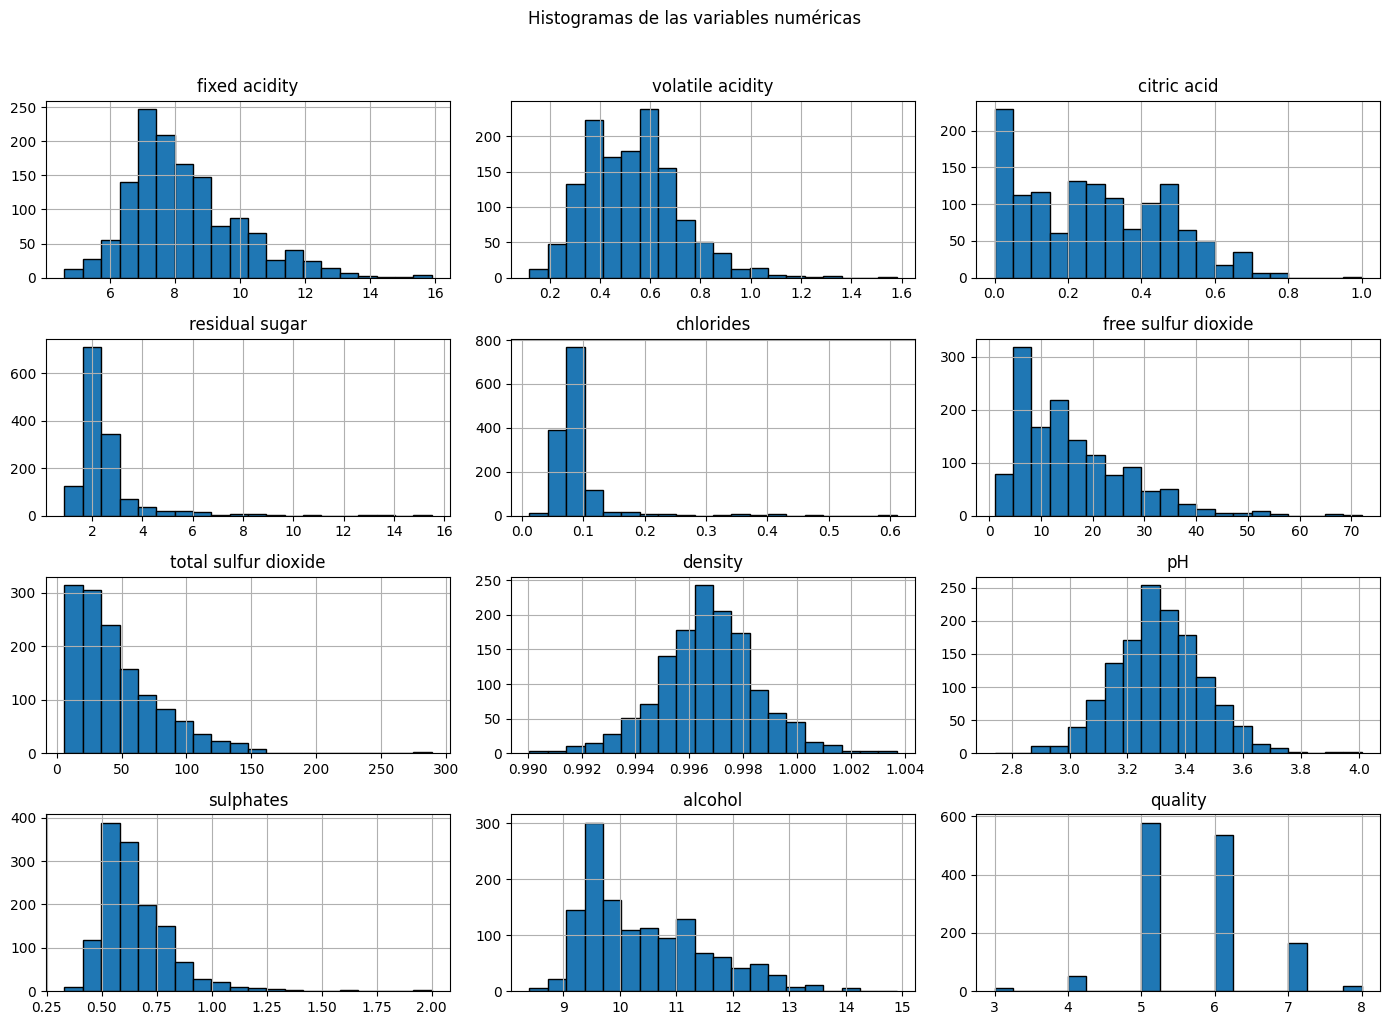

In [40]:
import matplotlib.pyplot as plt

df.drop(columns=["quality_binary"]).hist(figsize=(14, 10), bins=20, edgecolor="black")
plt.suptitle("Histogramas de las variables numéricas", y=1.02)
plt.tight_layout()
plt.show()

Breve análisis de los histogramas: Como se puede observar en las 12 variables, se rescatan las siguientes visualizaciones. 

**Density**: Se observa que sigue un comportamiento prácticamente muy similar al de pH; de tipo campana.

**pH**: Se observa que sigue una forma muy simétrica y centrada en la de la distribución campana.

**Quality:** No sigue una distribución normal pues es una variable discreta, no de tipo continua.

Todos los demás histogramas estan sesgados de ligeramente a muy claramente hacia la derecha, con algunos cuantos valores perdidos.

##### **Boxplots de variables numéricas**

Los boxplots permiten analizar la distribución de las variables numéricas mediante la mediana, los cuartiles, el rango intercuartílico y la presencia de posibles valores atípicos. Estos gráficos son útiles para identificar dispersión y outliers en cada característica del dataset.

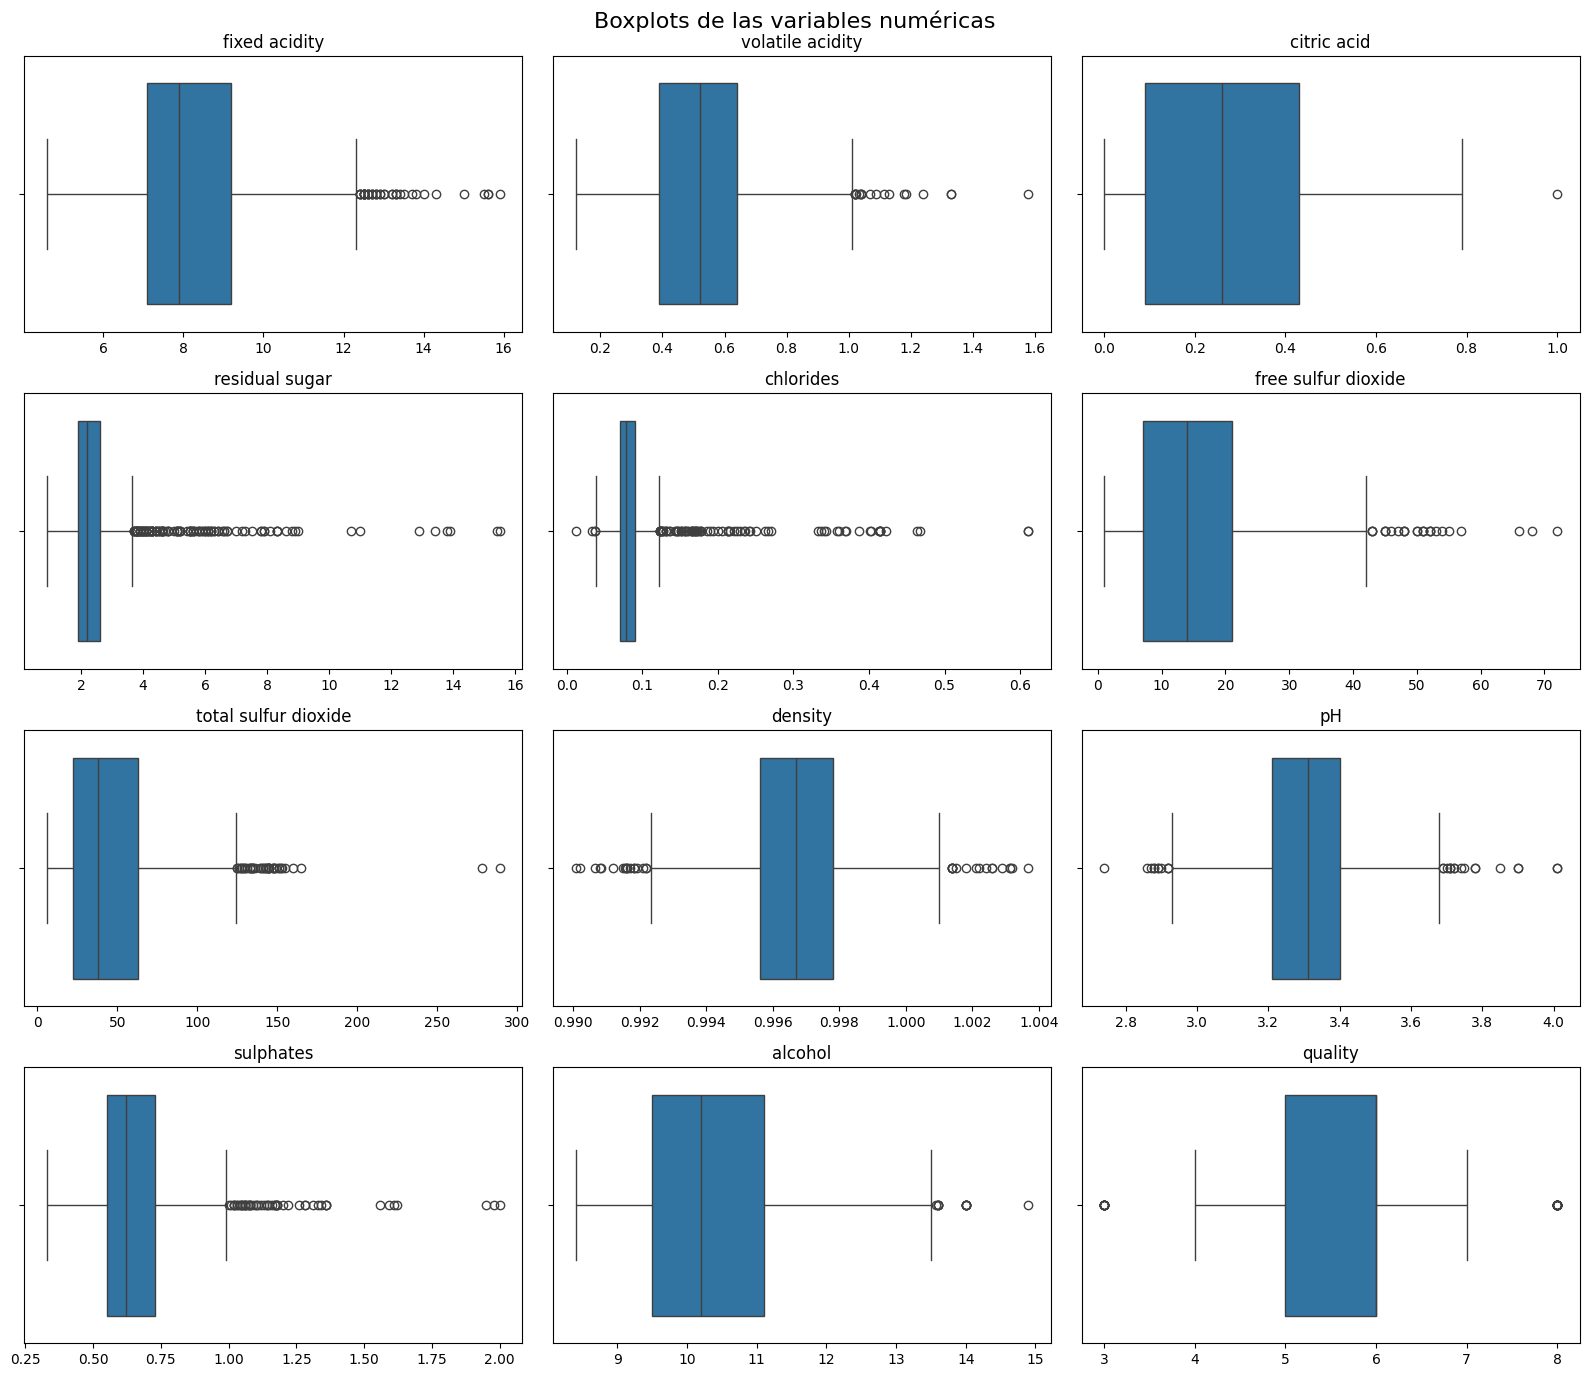

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

columnas = df.drop(columns=["quality_binary"]).columns

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(columnas):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f"{col}")
    axes[i].set_xlabel("")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Boxplots de las variables numéricas", fontsize=16)
plt.tight_layout()
plt.show()

Análisis de los boxplots: A partir de los boxplots individuales se observa que varias variables presentan valores outliers. En particular, residual sugar, chlorides, free sulfur dioxide, total sulfur dioxide y sulphates muestran una cantidad muy alta de outliers hacia valores altos, lo cual tiene concordancia con el sesgo a la derecha observado anteriormente en los histogramas.
Por otro lado, variables como density y pH presentan una distribución más compacta y una menor dispersión, aunque también muestran algunos valores extremos. En el caso de fixed acidity, volatile acidity y alcohol, se observan outliers moderados, pero con una concentración principal de datos intermedios.

##### **Diagramas de dispersión respecto al target**

Un diagrama de dispersión (scatter plot) es una representación gráfica que permite visualizar la relación entre dos variables. En este caso, se utiliza para observar cómo cada característica del dataset se relaciona con la variable objetivo (quality_binary), recordar que la variable objetivo es considerado como el "punto central" del análisis de los datos. Cada punto representa una observación del conjunto de datos, permitiendo identificar patrones, tendencias o posibles anomalías.

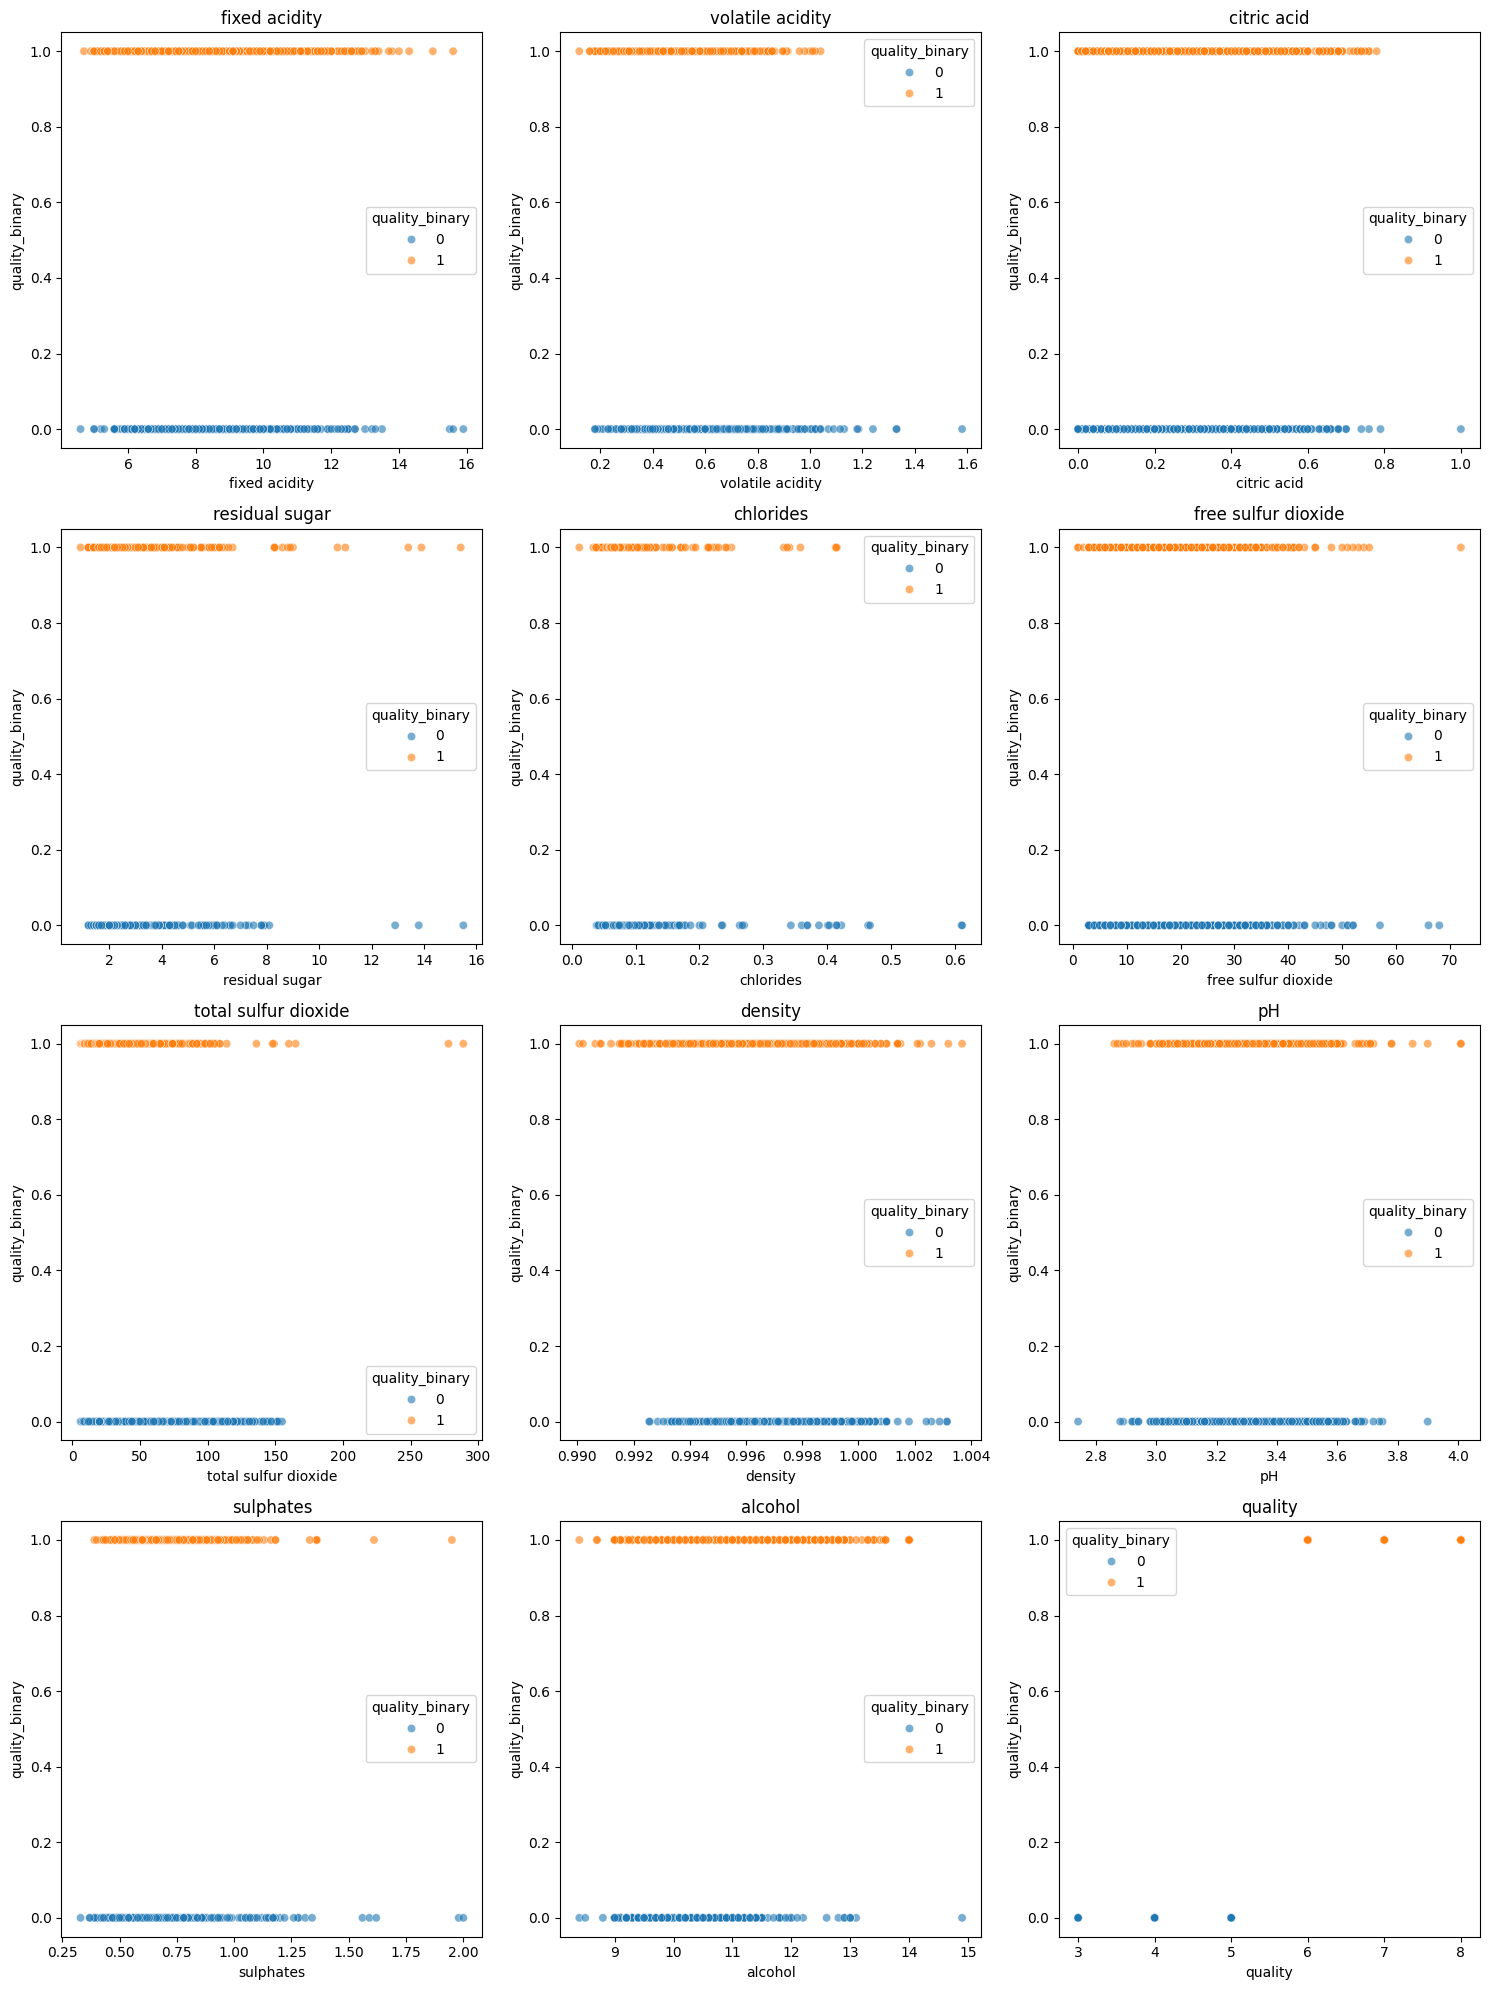

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

target = "quality_binary"

features = [col for col in df.columns if col != target]

n = len(features)
cols = 3
rows = math.ceil(n / cols)

plt.figure(figsize=(15, 5 * rows))

for i, col in enumerate(features, 1):
    plt.subplot(rows, cols, i)
    sns.scatterplot(data=df, x=col, y=target, hue=target, alpha=0.6)
    plt.title(col)

plt.tight_layout()
plt.show()

Análisis sobre los diagramas de dispersión: A como se puede ver en los diagramas de dispersión, se observa que variables como el alcohol y volatile acidity muestran separación entre las clases, lo cual puede ser una pista para la predicción de la calidad del vino. Adicionalmente se detectaron valores atípicos en variables como el residual sugar, chlorides, entre otros.

Por lo tanto, se tendrá que eliminar los valores atípicos. Se puede hacer de muchas formas distintas, no obstante, en este caso se utilizará usando el IQR con los cuartiles. No se trata de borrar filas solo por borrar, sino de capar los extremos usando los límites del IQR. De esta manera no se pierden demasiados datos. Este proceso se realizará justamente después de la división/separación de los datos; y solo se calcula el IQR solo con el train.

##### **Matriz de correlación con mapa de calor**

Una matriz de correlación muestra la relación lineal entre variables numéricas. Sus valores van de -1 a 1, donde valores cercanos a 1 indican relación positiva fuerte, cercanos a -1 relación negativa fuerte, y cercanos a 0 poca o ninguna relación. Con el mapa de calor es únicamente para poder visualizar más fácil y rápidamente las relaciones.

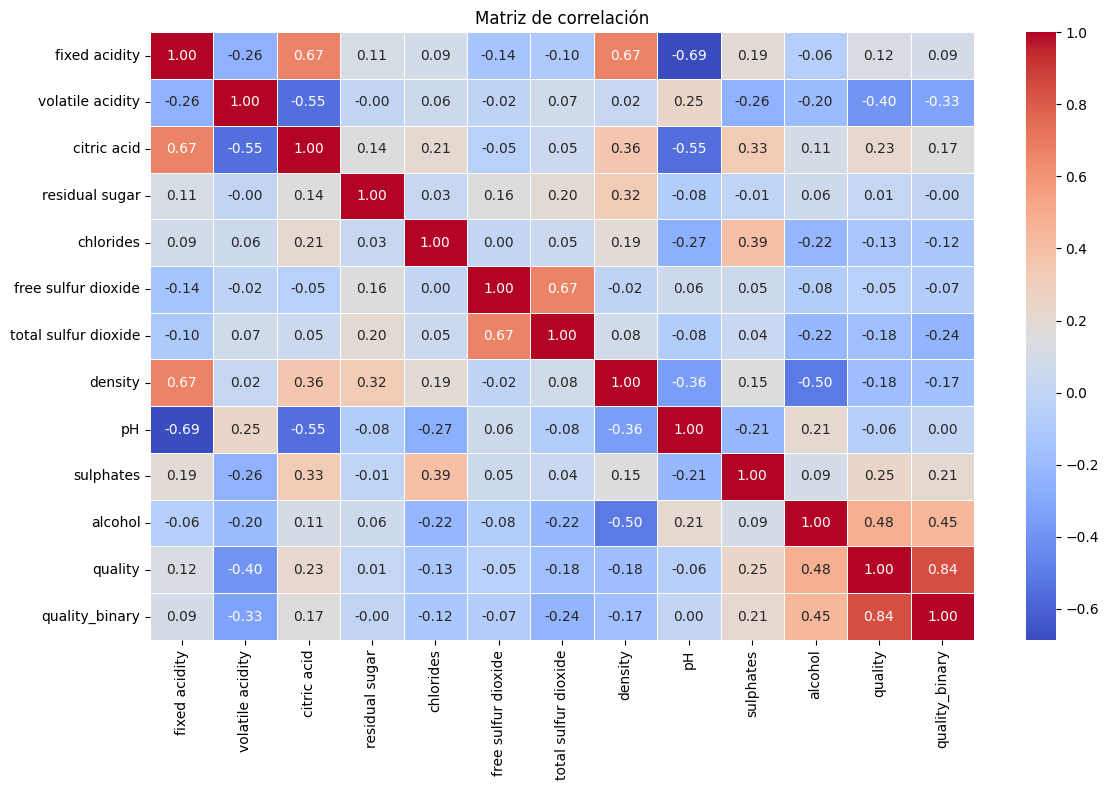

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

Análisis de la matriz de correlación: Se puede ver que alcohol es la variable con mayor correlación positiva con quality_binary (0.45), por lo que parece ser una de las características más buenas para distinguir vinos de mejor calidad. Mientras tanto, volatile acidity presenta una correlación negativa moderada (-0.33), lo que indica que valores más altos de esta variable se asocian con vinos de menor calidad. También visualizan total sulfur dioxide con una correlación negativa débil a moderada (-0.24) y sulphates con una correlación positiva baja (0.21).

Por otro lado, la matriz también muestra relaciones importantes entre variables independientes, por ejemplo entre fixed acidity y citric acid (0.67), fixed acidity y density (0.67), free sulfur dioxide y total sulfur dioxide (0.67), y una correlación negativa fuerte entre fixed acidity y pH (-0.69). Esto da a entender que algunas variables podrían dar información innecesaria y confusa.

##### **Búsqueda de las 6 principales variables** 

In [44]:
corr_target = df.drop(columns=["quality"]).corr(numeric_only=True)["quality_binary"] \
    .drop("quality_binary") \
    .sort_values(key=lambda s: s.abs(), ascending=False)

print(corr_target)

alcohol                 0.446176
volatile acidity       -0.327195
total sulfur dioxide   -0.235046
sulphates               0.211365
density                -0.168958
citric acid             0.167903
chlorides              -0.115071
fixed acidity           0.091761
free sulfur dioxide    -0.069207
pH                      0.004693
residual sugar         -0.002371
Name: quality_binary, dtype: float64


"Para la selección de características se utilizó como criterio principal el coeficiente de correlación de Pearson entre cada variable numérica y la variable objetivo que se eligió anteriormente. Se seleccionaron las seis variables con mayor valor absoluto de correlación: alcohol (0.435), volatile acidity (-0.321), total sulfur dioxide (-0.232), sulphates (0.218), citric acid (0.159) y density (-0.159). Las demás variables fueron descartadas por presentar una relación más débil con la variable a predecir. Curiosamente esto concuerda con lo que se vio en la matriz de correlación y los distintos diagramas, en donde se ve que el alcohol fue el que tiene la relación más fuerte con el target, y en donde total sulfur dioxide y sulphates también destacan con buenos valores.

Por lo tanto se eligen las siguientes 6 variables:

In [45]:
selected_features = [
    "alcohol",
    "volatile acidity",
    "total sulfur dioxide",
    "sulphates",
    "density",
    "citric acid"
]

##### **División del data-set** 

La división del conjunto de datos es un paso muy importante para el entrenamiento de modelos de aprendizaje automático, ya que permite evaluar que tan efectivo es el modelo en datos no vistos/desconocidos. Como se vió en clase, esto ayuda a evitar el overfitting y a estimar de forma más realista los resultados.

Existen formas técnicas para dividir los datos, como la división simple (train/test), cross-validation y el uso de conjuntos separados de entrenamiento, validación y prueba (como se hizo con la tarea #1). En este caso, se optó por dividir el dataset en tres subconjuntos: entrenamiento, validación y prueba.

In [46]:
from sklearn.model_selection import train_test_split

selected_features = [
    "alcohol",
    "volatile acidity",
    "total sulfur dioxide",
    "sulphates",
    "density",
    "citric acid"
]

X = df[selected_features]
y = df["quality_binary"]

# 70% entrenamiento, 30% temporal
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# 15% validación, 15% prueba
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Distribución train:")
print(y_train.value_counts(normalize=True))

print("\nDistribución val:")
print(y_val.value_counts(normalize=True))

print("\nDistribución test:")
print(y_test.value_counts(normalize=True))

Distribución train:
quality_binary
1    0.528917
0    0.471083
Name: proportion, dtype: float64

Distribución val:
quality_binary
1    0.529412
0    0.470588
Name: proportion, dtype: float64

Distribución test:
quality_binary
1    0.529412
0    0.470588
Name: proportion, dtype: float64


Como se puede ver, se verificó que la distribución de las clases de los subconjuntos se viera reflejada. Puede verse que las proporciones son muy similares entre sí, lo que da a entender que el muestreo estratificado está aplicado correctamente, así evitando cualquier tipo de sesgo en los resultados que se vayan a hacer. Ahora si, después de hacer la división del data-set, se aplica el IQR.

##### **Aplicación del IQR** 

Como se mencionó anteriormente, se aplicará el método del rango intercuartílico (IQR), este consiste en una técnica de estadística utilizada para detectar y tratar cualquier indicio de valores atípicos en un conjunto de datos (en este caso el data-set). Este consiste en la distribución de los datos usando los cuartiles, permitiendo que se puedan identificar las observaciones que se alejan mucho al comportamiento general que ya se tiene.

**Explicación breve del algoritmo:**

**1. Se calculan los cuartiles:** El Q1 corresponde al percentil 25 y el Q3 corresponde al percentil 75.


**2. Se calcula el rango intercuartílico:** En donde se sabe que el **IQR = Q3 - Q1**


**3. Se define el límite inferior y superior:** En donde se sabe que el **Límite Inferior = Q1 - 1.5 * IQR** Y **Límite Superior = Q3 + 1.5 * IQR**


**4. Identificar outliers:** Usando la condición de: **Si x < Límite Inferior o x > Límite Superior**

**5. Tratamiento:** Se realiza el capado, en donde los valores pequeños se remplazan por el límite inferior y los valores mayores se remplazan por el límite superior.

In [47]:
X_train_iqr = X_train.copy()
X_val_iqr = X_val.copy()
X_test_iqr = X_test.copy()

for col in selected_features:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    X_train_iqr[col] = X_train_iqr[col].clip(lower, upper)
    X_val_iqr[col] = X_val_iqr[col].clip(lower, upper)
    X_test_iqr[col] = X_test_iqr[col].clip(lower, upper)

##### **Escalar los datos** 

Cuando se hace referencia a escalar los datos, se refiere a poner todas las variables en una misma escala. Esto se debe a que hay variables con rangos muy distintos, haciendo que el modelo le dé más importancia a las variables grandes sobre las pequeñas.

El escalado consiste en que cada variable tenga una media de aproximadamente 0 y una desviación estándar aproximadamente de 1. Se utilizará la fórmula de StandardScaler ().

In [48]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_iqr)
X_val_scaled = scaler.transform(X_val_iqr)
X_test_scaled = scaler.transform(X_test_iqr)

### Implementación con PyTorch

##### **Convertir los datos escalados a tensores** 

Este paso consiste en transformar los datos escalados a tensores para que se puedan utilizar en PyTorch, esto debido a que este framework maneja este tipo de estructura para poder así entrenar los modelos. Además, se tiene que ajustar la forma de la variables objetivo para que pueda ser compatible con la forma binaria.

In [49]:
import torch

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

print("X_train_tensor:", X_train_tensor.shape)
print("y_train_tensor:", y_train_tensor.shape)

X_train_tensor: torch.Size([951, 6])
y_train_tensor: torch.Size([951, 1])


Como se puede observar, se tiene 951 filas con 6 features y está mostrado en formato de columna para que se pueda utilizar con PyTorch.

##### **Crear los Data-Set y Data Loader** 

Para poder realizar la implementación, es necesario que se creen estructuras para poder permitir alimentar los datos al modelo. De esta manera se logra facilitar el entrenamiento en si, además de poder mejorar la eficiencia y controlar el tamaño del batch.

In [50]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

Como se puede observar, se utilizó el TensorDataset para poder construir los conjuntos de datos para preparar el entrenamiento y la validación. Después se prepararon con el DataLoader para procesarlos por lotes. Además de mezclar los datos, lo cual es muy importante!

##### **Definir el modelo de regresión logística en PyTorch** 

Es aquí donde finalmente se define el modelo de regresión logística en PyTorch. Se debe recordar que como se trata de una clasificación de tipo binaria (BUENO = 1 y MALO = 0), el modelo debe tener una sola capa lineal con una salida.

In [51]:
import torch.nn as nn

class LogisticRegressionModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        return self.linear(x)

##### **Inicializar el modelo** 

En este paso se busca crear una instancia del modelo, en donde también se define la función de perdida adecuada para la clasificación binaria que se mencionó anteriormente, además se debe elegir el optimizador para así actualizar los pesos del propio modelo.

In [52]:
model = LogisticRegressionModel(X_train_tensor.shape[1])

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

Como se puede observar, el modelo se inicializa con los seis variables de entrada, además se hizo una función de pérdida para que sea apropiada para la clasificación binaria. Es importante mencionar que también se utilizó el optimizador Adam con una tasa de aprendizaje inicial del 0.01.

##### **Entrenar el modelo** 

Esta es la parte más interesante, pues es donde ya se logra entrenar el modelo. Primero se entrenará para poder comprobar que el modelo funciona bien; se espera que la pérdida disminuya y el flujo completo esté bien, antes de ejecutar los 10 experimentos que pide la tarea.

A continuación se presenta la función de entrenamiento:

In [53]:
def train_one_epoch(model, train_loader, criterion, optimizer):
    model.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)

Como se puede ver se actualizan los pesos del modelo mediante la retropropagación.

Después continúa la fase de validación, en donde se evalúa que el desempeño del modelo sea el esperado, esto sin modificar sus parámetros. A continuación se presenta:

In [54]:
def validate_one_epoch(model, val_loader, criterion):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            total_loss += loss.item()

    return total_loss / len(val_loader)

Con estas dos funciones después continua con el loop principal del entrenamiento, el cual se presenta a continuación:

In [55]:
epochs = 50

train_losses = []
val_losses = []

for epoch in range(epochs):
    
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss = validate_one_epoch(model, val_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

Epoch 1/50 | Train Loss: 0.7630 | Val Loss: 0.6465
Epoch 2/50 | Train Loss: 0.6048 | Val Loss: 0.5561
Epoch 3/50 | Train Loss: 0.5527 | Val Loss: 0.5267
Epoch 4/50 | Train Loss: 0.5357 | Val Loss: 0.5139
Epoch 5/50 | Train Loss: 0.5279 | Val Loss: 0.5072
Epoch 6/50 | Train Loss: 0.5244 | Val Loss: 0.5038
Epoch 7/50 | Train Loss: 0.5239 | Val Loss: 0.5006
Epoch 8/50 | Train Loss: 0.5225 | Val Loss: 0.4994
Epoch 9/50 | Train Loss: 0.5217 | Val Loss: 0.5016
Epoch 10/50 | Train Loss: 0.5208 | Val Loss: 0.4995
Epoch 11/50 | Train Loss: 0.5198 | Val Loss: 0.4983
Epoch 12/50 | Train Loss: 0.5193 | Val Loss: 0.4971
Epoch 13/50 | Train Loss: 0.5206 | Val Loss: 0.4971
Epoch 14/50 | Train Loss: 0.5209 | Val Loss: 0.4985
Epoch 15/50 | Train Loss: 0.5192 | Val Loss: 0.5000
Epoch 16/50 | Train Loss: 0.5177 | Val Loss: 0.4982
Epoch 17/50 | Train Loss: 0.5180 | Val Loss: 0.4971
Epoch 18/50 | Train Loss: 0.5193 | Val Loss: 0.4982
Epoch 19/50 | Train Loss: 0.5188 | Val Loss: 0.4978
Epoch 20/50 | Train L

##### **Ejecución de los 10 entrenamientos** 

Primero se definen los experimentos:

In [56]:
experiments = [
    {"lr": 0.001, "batch": 16, "epochs": 20},
    {"lr": 0.001, "batch": 32, "epochs": 20},
    {"lr": 0.001, "batch": 64, "epochs": 20},
    {"lr": 0.005, "batch": 16, "epochs": 20},
    {"lr": 0.005, "batch": 32, "epochs": 20},
    {"lr": 0.005, "batch": 64, "epochs": 20},
    {"lr": 0.01,  "batch": 16, "epochs": 20},
    {"lr": 0.01,  "batch": 32, "epochs": 20},
    {"lr": 0.01,  "batch": 64, "epochs": 20},
    {"lr": 0.01,  "batch": 32, "epochs": 50},
]

Después se realiza con un loop de entrenamiento:

In [57]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

# Listas para almacenar resultados e historiales de pérdida
results = []
loss_history = {} 

# Usamos BCEWithLogitsLoss: estable y compatible con modelos sin Sigmoide en el forward
criterion = nn.BCEWithLogitsLoss()

print("Iniciando fase de experimentación...")

# Iteramos sobre los 10 experimentos definidos
for i, exp in enumerate(experiments): 
    # 1. Instanciar el modelo y el optimizador
    model = LogisticRegressionModel(input_dim=X_train_tensor.shape[1])
    optimizer = optim.Adam(model.parameters(), lr=exp["lr"])
    
    # 2. Configurar el DataLoader para el batch actual
    train_loader = DataLoader(train_dataset, batch_size=exp["batch"], shuffle=True)
    
    train_losses = []
    val_losses = []
    
    # 3. Ciclo de entrenamiento (Epochs)
    for epoch in range(exp["epochs"]):
        model.train()
        epoch_train_loss = 0
        
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            
            # Forward pass
            outputs = model(batch_X)
            
            # CORRECCIÓN DE DIMENSIONES: Forzamos que el target sea [Batch, 1]
            batch_y_correct = batch_y.view(-1, 1).float()
            
            loss = criterion(outputs, batch_y_correct)
            
            # Backward pass
            loss.backward()
            optimizer.step()
            
            epoch_train_loss += loss.item()
            
        # Promedio de pérdida de entrenamiento en la época
        train_losses.append(epoch_train_loss / len(train_loader))
        
        # 4. Evaluación en Validación para la curva de aprendizaje (Loss)
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val_tensor)
            # CORRECCIÓN DE DIMENSIONES: Forzamos que el target sea [N, 1]
            y_val_correct = y_val_tensor.view(-1, 1).float()
            
            val_loss = criterion(val_outputs, y_val_correct)
            val_losses.append(val_loss.item())
            
    # Guardamos el historial para las gráficas del punto D
    loss_history[f"Exp_{i+1}"] = {"train": train_losses, "val": val_losses}
    
    # 5. Evaluación final para métricas comparativas
    model.eval()
    with torch.no_grad():
        logits = model(X_val_tensor)
        # Aplicamos sigmoide para convertir logits a probabilidades (0-1)
        probs = torch.sigmoid(logits).numpy().flatten()
        preds = (probs >= 0.5).astype(int)
        
    y_true = y_val_tensor.numpy()
    
    results.append({
        "Exp": i+1,
        "LR": exp["lr"],
        "Batch": exp["batch"],
        "Epochs": exp["epochs"],
        "Accuracy": accuracy_score(y_true, preds),
        "Precision": precision_score(y_true, preds, zero_division=0),
        "Recall": recall_score(y_true, preds, zero_division=0),
        "F1": f1_score(y_true, preds, zero_division=0),
        "AUC": roc_auc_score(y_true, probs)
    })

# Crear DataFrame con los resultados consolidado
results_df = pd.DataFrame(results)
print("¡Entrenamiento finalizado!")
display(results_df.sort_values(by="F1", ascending=False))

Iniciando fase de experimentación...
¡Entrenamiento finalizado!


,Exp,LR,Batch,Epochs,Accuracy,Precision,Recall,F1,AUC
1,2,0.001,32,20,0.740196,0.777778,0.712963,0.743961,0.823399
9,10,0.010,32,50,0.720588,0.762887,0.685185,0.721951,0.828607
5,6,0.005,64,20,0.715686,0.750000,0.694444,0.721154,0.820216
6,7,0.010,16,20,0.715686,0.755102,0.685185,0.718447,0.827739
8,9,0.010,64,20,0.710784,0.747475,0.685185,0.714976,0.826389
7,8,0.010,32,20,0.710784,0.747475,0.685185,0.714976,0.829379
4,5,0.005,32,20,0.705882,0.740000,0.685185,0.711538,0.827257
3,4,0.005,16,20,0.705882,0.740000,0.685185,0.711538,0.826871
0,1,0.001,16,20,0.696078,0.730000,0.675926,0.701923,0.825231
2,3,0.001,64,20,0.661765,0.719101,0.592593,0.649746,0.705150


### Visualización de las curvas de pérdida

A continuación, se presentan las curvas de aprendizaje (Loss de Entrenamiento vs. Loss de Validación) correspondientes a cada uno de los experimentos ejecutados. Estas gráficas son fundamentales para corroborar empíricamente que el modelo generaliza de manera adecuada. Un escenario ideal muestra ambas curvas descendiendo de forma asintótica, mientras que una separación donde la pérdida de validación aumenta indicaría *overfitting*.

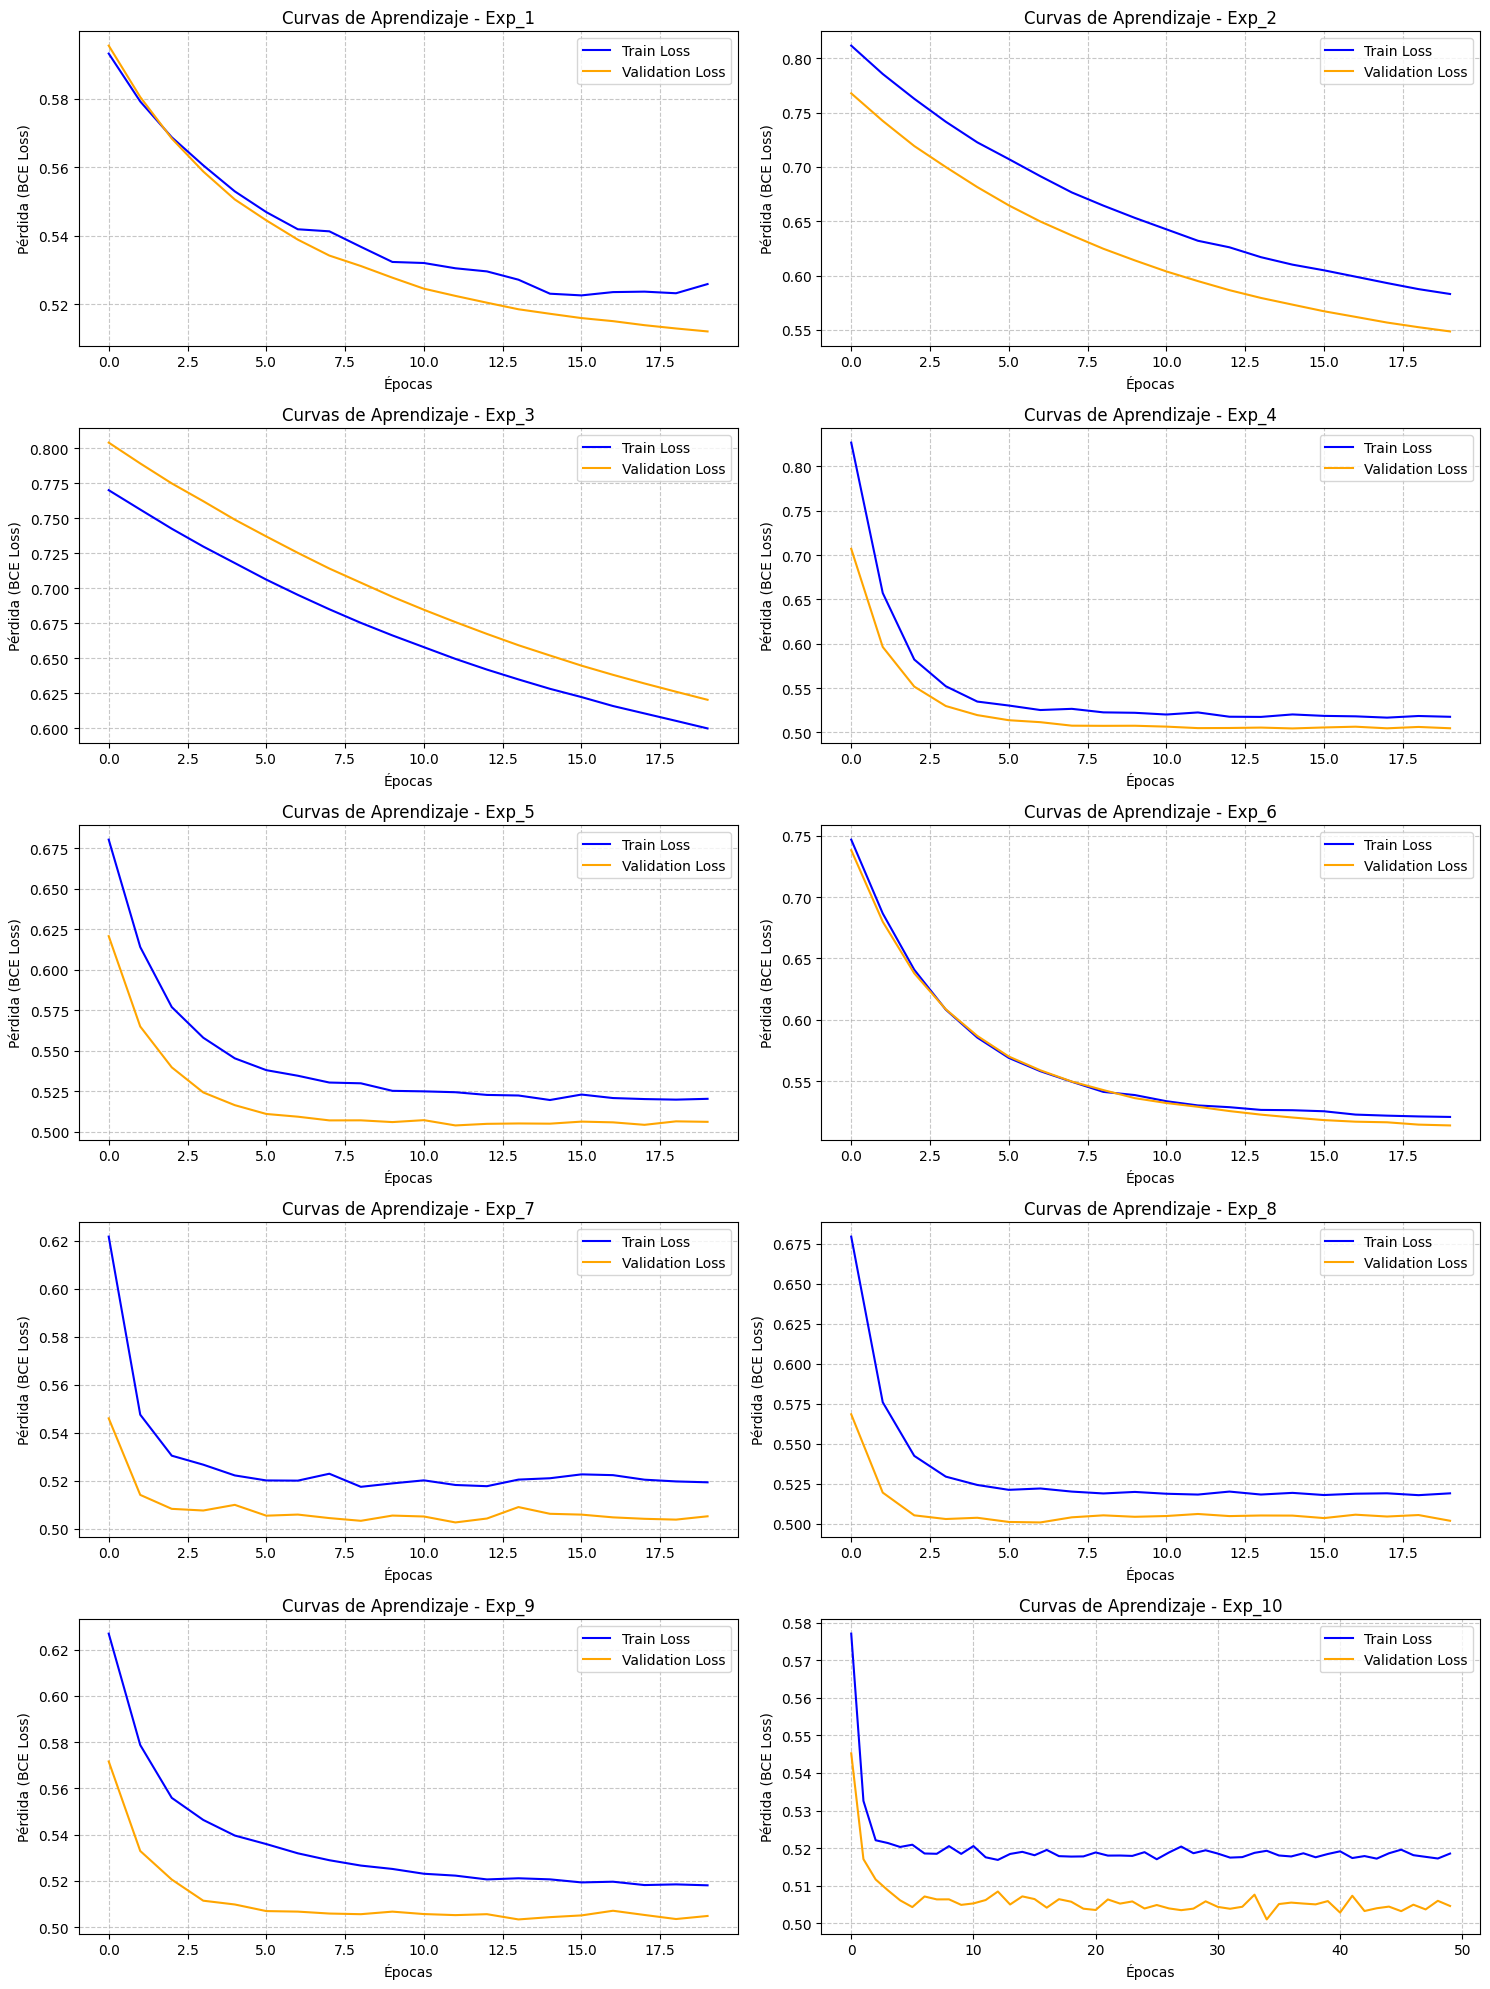

In [58]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(5, 2, figsize=(15, 20))
axes = axes.flatten()

for i in range(10):
    exp_name = f"Exp_{i+1}"
    hist = loss_history[exp_name]
    
    axes[i].plot(hist["train"], label='Train Loss', color='blue')
    axes[i].plot(hist["val"], label='Validation Loss', color='orange')
    
    axes[i].set_title(f'Curvas de Aprendizaje - {exp_name}')
    axes[i].set_xlabel('Épocas')
    axes[i].set_ylabel('Pérdida (BCE Loss)')
    axes[i].legend()
    axes[i].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Análisis de las Curvas de Aprendizaje

A partir de la visualización de las curvas de aprendizaje generadas para los distintos experimentos, donde se contrasta el error de entrenamiento (*Train Loss*) frente al error de validación (*Validation Loss*), se pueden extraer las siguientes observaciones técnicas respecto al proceso de optimización del modelo:

* **Convergencia del Modelo:** Se observa de manera generalizada que la función de costo en el conjunto de entrenamiento disminuye de forma asintótica y continua conforme avanzan las épocas. Esto demuestra que el algoritmo de optimización y el cálculo de gradientes están ajustando correctamente los pesos sin quedarse estancados desde las primeras iteraciones.
* **Capacidad de Generalización:** El aspecto más destacable es el comportamiento de la curva de validación, la cual acompaña el descenso de la curva de entrenamiento. El hecho de que el *Validation Loss* disminuya y se estabilice a la par del *Train Loss*, sin presentar divergencias hacia el final de las épocas, es un indicador bueno de que el modelo **no está sufriendo de *overfitting* (sobreajuste)**.
* **Sensibilidad a los Hiperparámetros:** Las variaciones en la suavidad de las curvas entre los diferentes gráficos evidencian el impacto directo de la tasa de aprendizaje (*learning rate*) y el tamaño del lote (*batch size*). Aquellos experimentos con curvas más estables e iteraciones menos ruidosas sugieren una configuración óptima que permite descensos de gradiente más seguros y consistentes.

**Conclusión de la Fase de Entrenamiento:**

La evaluación visual de estas métricas de pérdida confirma que la regresión logística ha logrado un proceso de aprendizaje saludable. El modelo es capaz de abstraer los patrones químicos fundamentales que determinan la calidad del vino, evitando la memorización estricta de los datos de entrenamiento. Esta estabilidad justifica avanzar hacia la selección del mejor experimento basándose en las métricas de rendimiento final (F1-Score, AUC).

--- 

#### Cuadro Comparativo de Entrenamientos

Para cumplir con los criterios de evaluación, en cada uno de los 10 experimentos se capturaron las métricas de rendimiento en el conjunto de validación. Las métricas seleccionadas para evaluar el desempeño de la regresión logística son: **Accuracy** (Exactitud), **Precision** (Precisión), **Recall** (Exhaustividad), **F1-Score** y el **AUC** (Área Bajo la Curva ROC).

A continuación se presenta el cuadro comparativo consolidado. La tabla ha sido ordenada de forma descendente tomando como criterio principal el **F1-Score**, ya que esta métrica ofrece un balance más robusto entre Precision y Recall frente a posibles desequilibrios en las clases del *dataset*.

In [59]:
# Ordenar los resultados por F1-Score
df_ordenado = results_df.sort_values(by="F1", ascending=False).reset_index(drop=True)

# Mostrar la tabla resaltando el valor más alto de cada métrica (en verde claro)
df_ordenado.style.highlight_max(
    subset=['Accuracy', 'Precision', 'Recall', 'F1', 'AUC'], 
    color='lightgreen', 
    axis=0
).format({
    'LR': '{:.4f}',
    'Accuracy': '{:.4f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'F1': '{:.4f}',
    'AUC': '{:.4f}'
})

,Exp,LR,Batch,Epochs,Accuracy,Precision,Recall,F1,AUC
0,2,0.0010,32,20,0.7402,0.7778,0.7130,0.7440,0.8234
1,10,0.0100,32,50,0.7206,0.7629,0.6852,0.7220,0.8286
2,6,0.0050,64,20,0.7157,0.7500,0.6944,0.7212,0.8202
3,7,0.0100,16,20,0.7157,0.7551,0.6852,0.7184,0.8277
4,9,0.0100,64,20,0.7108,0.7475,0.6852,0.7150,0.8264
5,8,0.0100,32,20,0.7108,0.7475,0.6852,0.7150,0.8294
6,5,0.0050,32,20,0.7059,0.7400,0.6852,0.7115,0.8273
7,4,0.0050,16,20,0.7059,0.7400,0.6852,0.7115,0.8269
8,1,0.0010,16,20,0.6961,0.7300,0.6759,0.7019,0.8252
9,3,0.0010,64,20,0.6618,0.7191,0.5926,0.6497,0.7052


### Análisis de Resultados y Selección del Modelo

A partir del cuadro comparativo generado, se observa una varianza significativa en el rendimiento de los modelos dependiendo de la configuración de hiperparámetros. El análisis detallado de las métricas revela los siguientes hallazgos técnicos:

* **El Equilibrio Óptimo y Dominio de Métricas:** El **Experimento 2** destaca de manera contundente como el mejor modelo general. No solo obtuvo el máximo **F1-Score (0.7440)**, sino que lideró casi todas las métricas de clasificación directa: Exactitud o *Accuracy* (0.7402), Precisión (0.7778) y Exhaustividad o *Recall* (0.7130). Su configuración ($LR = 0.001$, $Batch = 32$, $Epochs = 20$) logró el mejor punto de convergencia.
* **Capacidad de Separación (AUC):** Es importante notar que el **Experimento 8** obtuvo el valor más alto en el Área Bajo la Curva ROC (AUC = 0.8294). Esto indica que, a nivel de probabilidades crudas, el Experimento 8 separa mejor las clases que el Experimento 2 (AUC = 0.8234). Sin embargo, bajo el umbral de decisión estándar de 0.5, el Experimento 2 logró un mejor balance de predicciones reales (F1).
* **Impacto de los Hiperparámetros:** * **Tamaño de Lote (*Batch Size*):** Se evidencia que un tamaño de lote de 32 es el punto óptimo para este conjunto de datos. Los experimentos que utilizaron este tamaño (Exp 2, Exp 10, Exp 8) dominan la parte superior de la tabla. Por el contrario, tamaños de lote más grandes, como 64 (evidente en el Experimento 3, que quedó en último lugar), generaron actualizaciones de gradiente menos precisas, desplomando las métricas.
    * **Tasa de Aprendizaje (*Learning Rate*):** Una tasa de $0.001$ demostró ser la más efectiva cuando se emparejó con el lote ideal (Exp 2). Sin embargo, tasas más altas como $0.01$ (Exp 10) demostraron ser competitivas, logrando el segundo mejor F1-Score (0.7220) al compensar con un mayor número de épocas (50).

**Selección del Modelo Definitivo:**

Basado en la evidencia cuantitativa, se selecciona oficialmente el **Experimento 2** como el modelo definitivo. Su capacidad para liderar en Precisión, Recall y F1-Score simultáneamente garantiza que es el clasificador más robusto y simétrico de la prueba, asegurando que minimizará tanto los Falsos Positivos como los Falsos Negativos al enfrentarse al conjunto de datos de prueba (*Testing Set*).

---

### Análisis de Resultados y Evaluación Final

Habiendo determinado mediante el conjunto de validación que el **Experimento 2** ($LR = 0.001$, $Batch = 32$, $Epochs = 20$) posee la configuración óptima de hiperparámetros (maximizando el F1-Score y balanceando las métricas de clasificación), se procede a la etapa de evaluación final.

Para comprobar la capacidad real de generalización del modelo, se utilizará el **Conjunto de Prueba (*Testing Set*)**. Estos datos fueron separados al inicio mediante muestreo estratificado y el modelo jamás ha tenido contacto con ellos, por lo que representan una simulación fidedigna de su desempeño en un entorno de producción.

Re-entrenando el modelo definitivo (Experimento 2)...

MÉTRICAS FINALES CON EL TESTING SET
Accuracy:	0.7549
Precision:	0.7900
Recall:	0.7315
F1-Score:	0.7596
AUC:	0.8273


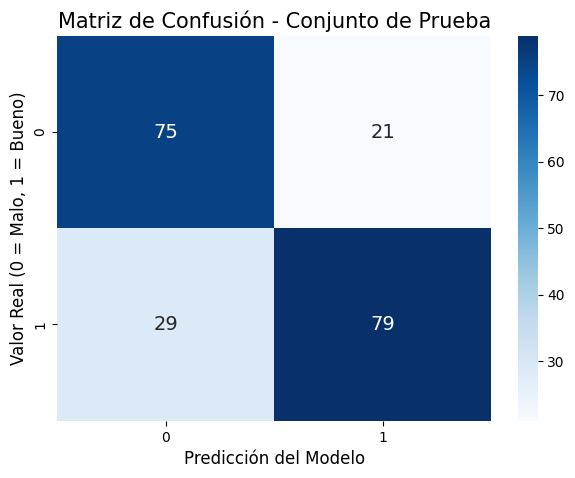

In [61]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

print("Re-entrenando el modelo definitivo (Experimento 2)...")

# configuración del modelo ganador
mejor_lr = 0.001
mejor_batch = 32
mejores_epochs = 20

modelo_final = LogisticRegressionModel(input_dim=X_train_tensor.shape[1])
optimizador_final = optim.Adam(modelo_final.parameters(), lr=mejor_lr)
criterio_final = nn.BCEWithLogitsLoss()

train_loader_final = DataLoader(train_dataset, batch_size=mejor_batch, shuffle=True)

# entrenamiento final
modelo_final.train()
for epoch in range(mejores_epochs):
    for batch_X, batch_y in train_loader_final:
        optimizador_final.zero_grad()
        outputs = modelo_final(batch_X)
        loss = criterio_final(outputs, batch_y.view(-1, 1).float())
        loss.backward()
        optimizador_final.step()

# evaluación con el conjunto de testing
modelo_final.eval()
with torch.no_grad():
    test_logits = modelo_final(X_test_tensor)
    test_probs = torch.sigmoid(test_logits).numpy().flatten()
    test_preds = (test_probs >= 0.5).astype(int)

y_test_true = y_test_tensor.numpy()

# captura de métricas finales
metricas_test = {
    "Accuracy": accuracy_score(y_test_true, test_preds),
    "Precision": precision_score(y_test_true, test_preds, zero_division=0),
    "Recall": recall_score(y_test_true, test_preds, zero_division=0),
    "F1-Score": f1_score(y_test_true, test_preds, zero_division=0),
    "AUC": roc_auc_score(y_test_true, test_probs)
}

print("\nMÉTRICAS FINALES CON EL TESTING SET")
for metrica, valor in metricas_test.items():
    print(f"{metrica}:\t{valor:.4f}")

# generación de la matriz de confusión
cm = confusion_matrix(y_test_true, test_preds)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 14})
plt.title('Matriz de Confusión - Conjunto de Prueba', fontsize=15)
plt.ylabel('Valor Real (0 = Malo, 1 = Bueno)', fontsize=12)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.show()

#### Discusión de Resultados y Matriz de Confusión

Al someter el modelo óptimo al conjunto de pruebas, se obtuvieron las siguientes métricas de rendimiento final: **Accuracy de 0.7549**, **Precision de 0.7900**, **Recall de 0.7315**, **F1-Score de 0.7596** y un **AUC de 0.8273**. 

Al comparar estos resultados finales con los obtenidos durante la fase de validación (donde el F1-Score fue de 0.7440), se observa que no solo no hubo degradación del rendimiento, sino que el modelo logró una leve mejora en su capacidad de generalización. Esto corrobora el éxito del proceso metodológico: el modelo abstrajo correctamente la información y no sufrió de *overfitting*, manteniendo su robustez predictiva frente a datos completamente nuevos.

**Análisis de la Matriz de Confusión:**
La matriz de confusión ofrece una visión detallada de los aciertos y errores del clasificador sobre un total de 204 muestras en un escenario real:

1. **Verdaderos Positivos (TP) y Verdaderos Negativos (TN):** El modelo clasificó de forma correcta **79** vinos de buena calidad y **75** vinos de baja calidad. Esta alta concentración en la diagonal principal evidencia que las 6 características químicas seleccionadas poseen el peso matemático suficiente para separar ambas clases de forma efectiva.
2. **Errores de Tipo I (Falsos Positivos):** En **21** ocasiones, el modelo predijo erróneamente que un vino era de "BUENA" calidad cuando en la realidad era malo. 
3. **Errores de Tipo II (Falsos Negativos):** El modelo catalogó **29** vinos de "MALA" calidad que, en la realidad, eran buenos. 

En conclusión, la proximidad métrica entre los errores Tipo I (21) y Tipo II (29) demuestra un clasificador equilibrado y estable, producto del uso de muestreo estratificado durante la partición de datos. El modelo de regresión logística desarrollado en PyTorch cumple satisfactoriamente con el objetivo de catalogar la calidad del vino basándose de forma exclusiva en su perfil químico.